In [29]:
from datasets import Dataset, ClassLabel
from transformers import (
 AutoTokenizer,
 AutoModelForSequenceClassification,
 TrainingArguments,
 Trainer,
 DataCollatorWithPadding
)

In [30]:
import numpy as np
from sklearn.metrics import accuracy_score, precision_recall_fscore_support
import pandas as pd
MODEL_A = "distilbert-base-uncased"
LABELS = [
 "authentication", "network", "deployment", "database",
 "gpu", "api", "package", "general",
]
label2id = {label: i for i, label in enumerate(LABELS)}
id2label = {i: label for label, i in label2id.items()}
tokenizer_a = AutoTokenizer.from_pretrained(MODEL_A)
model_a = AutoModelForSequenceClassification.from_pretrained(
 MODEL_A,
 num_labels=len(LABELS),
 label2id=label2id,
 id2label=id2label,
)

def tokenize_a(batch):
 return tokenizer_a(batch["text"], truncation=True, max_length=128)

def compute_cls_metrics(eval_pred):
 logits, labels = eval_pred
 preds = np.argmax(logits, axis=-1)
 p, r, f1, _ = precision_recall_fscore_support(
 labels, preds, average="macro", zero_division=0
 )
 return {
 "accuracy": accuracy_score(labels, preds),
 "precision_macro": p,
 "recall_macro": r,
 "f1_macro": f1,
 }
# TODO(student 1): load/construct at least 12 examples per intent,
# then create stratified train/validation/test splits.

dataset = Dataset.from_csv("/content/technical_support_intents_50_per_label.csv")
label_feature = ClassLabel(names=LABELS)

dataset = dataset.map(
    lambda x: {
        "label": label_feature.str2int(x["label"])
    }
)

dataset = dataset.cast_column(
    "label",
    label_feature
)


Loading weights:   0%|          | 0/100 [00:00<?, ?it/s]

[transformers] DistilBertForSequenceClassification LOAD REPORT from: distilbert-base-uncased
Key                     | Status     | 
------------------------+------------+-
vocab_transform.bias    | UNEXPECTED | 
vocab_layer_norm.bias   | UNEXPECTED | 
vocab_projector.bias    | UNEXPECTED | 
vocab_layer_norm.weight | UNEXPECTED | 
vocab_transform.weight  | UNEXPECTED | 
classifier.weight       | MISSING    | 
classifier.bias         | MISSING    | 
pre_classifier.weight   | MISSING    | 
pre_classifier.bias     | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Generating train split: 0 examples [00:00, ? examples/s]

Map:   0%|          | 0/400 [00:00<?, ? examples/s]

Casting the dataset:   0%|          | 0/400 [00:00<?, ? examples/s]

In [31]:
split = dataset.train_test_split(
    test_size=0.4,
    stratify_by_column="label",
    seed=42
)

train_a = split["train"]
temp_a = split["test"]

temp_split = temp_a.train_test_split(
    test_size=0.5,
    stratify_by_column="label",
    seed=42
)

val_a = temp_split["train"]
test_a = temp_split["test"]

In [32]:
train_a = train_a.map(tokenize_a, batched=True)
val_a = val_a.map(tokenize_a, batched=True)
test_a = test_a.map(tokenize_a, batched=True)

Map:   0%|          | 0/240 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

Map:   0%|          | 0/80 [00:00<?, ? examples/s]

In [33]:
data_collator = DataCollatorWithPadding(
    tokenizer=tokenizer_a
)

In [34]:
args_a = TrainingArguments(
 output_dir="models/intent_classifier",
 learning_rate=2e-5,
 per_device_train_batch_size=8,
 per_device_eval_batch_size=8,
 num_train_epochs=10,
 eval_strategy="epoch",
 save_strategy="epoch",
 load_best_model_at_end=True,
 metric_for_best_model="f1_macro",
 greater_is_better=True,
 report_to="none",
)

In [35]:
trainer_a = Trainer(
 model=model_a,
 args=args_a,
 train_dataset=train_a,
 eval_dataset=val_a,
 compute_metrics=compute_cls_metrics,
 data_collator=data_collator
)
trainer_a.train()
trainer_a.evaluate(test_a)
trainer_a.save_model("models/intent_classifier")
tokenizer_a.save_pretrained("models/intent_classifier")

Epoch,Training Loss,Validation Loss,Accuracy,Precision Macro,Recall Macro,F1 Macro
1,No log,1.856914,0.687500,0.775841,0.687500,0.670945
2,No log,1.457295,0.775000,0.802379,0.775000,0.758603
3,No log,1.102376,0.887500,0.896185,0.887500,0.885951
4,No log,0.852684,0.887500,0.894192,0.887500,0.886379
5,No log,0.664099,0.887500,0.894192,0.887500,0.886379
6,No log,0.567461,0.862500,0.867677,0.862500,0.862114
7,No log,0.495207,0.887500,0.894823,0.887500,0.885500
8,No log,0.456781,0.875000,0.881187,0.875000,0.873031
9,No log,0.439221,0.887500,0.891414,0.887500,0.886558
10,No log,0.432213,0.887500,0.891414,0.887500,0.886558


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Training Loss,Validation Loss,Epoch,Accuracy,Precision Macro,Recall Macro,F1 Macro
No log,0.356593,10,0.925000,0.930997,0.925000,0.925195


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

('models/intent_classifier/tokenizer_config.json',
 'models/intent_classifier/tokenizer.json')

In [36]:
pred_output = trainer_a.predict(test_a)

logits = pred_output.predictions
y_true = pred_output.label_ids
y_pred = np.argmax(logits, axis=-1)

In [37]:
from sklearn.metrics import f1_score

macro_f1 = f1_score(
    y_true,
    y_pred,
    average="macro"
)

print("Macro F1:", macro_f1)

Macro F1: 0.9251946153261943


In [38]:
from sklearn.metrics import precision_recall_fscore_support

precision, recall, f1, support = precision_recall_fscore_support(
    y_true,
    y_pred,
    labels=range(len(LABELS)),
    average=None,
    zero_division=0,
)

In [39]:
results_df = pd.DataFrame({
    "class": LABELS,
    "precision": precision,
    "recall": recall,
    "f1": f1,
    "support": support,
})

print(results_df)

            class  precision  recall        f1  support
0  authentication   1.000000     0.8  0.888889       10
1         network   0.909091     1.0  0.952381       10
2      deployment   0.900000     0.9  0.900000       10
3        database   0.888889     0.8  0.842105       10
4             gpu   1.000000     1.0  1.000000       10
5             api   0.750000     0.9  0.818182       10
6         package   1.000000     1.0  1.000000       10
7         general   1.000000     1.0  1.000000       10


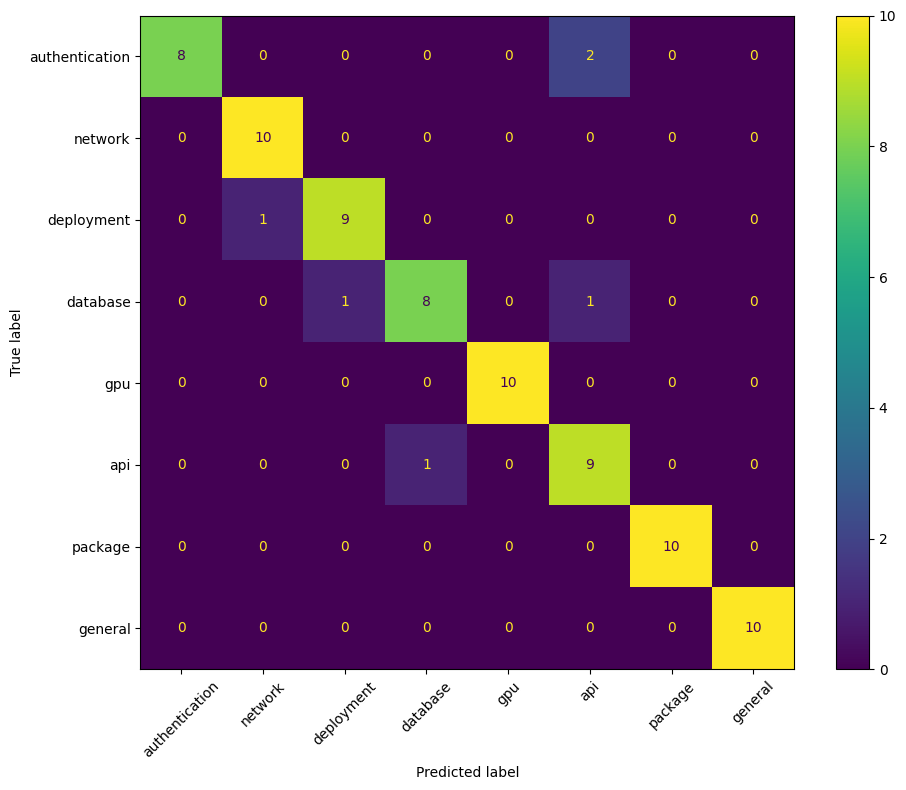

In [40]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

cm = confusion_matrix(
    y_true,
    y_pred,
    labels=range(len(LABELS))
)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=LABELS
)

fig, ax = plt.subplots(figsize=(10, 8))

disp.plot(
    ax=ax,
    xticks_rotation=45
)

plt.tight_layout()
plt.show()